# London Planning: Approval, Rejection and Decision Times for Full Applications

**Question:** How do approval and rejection rates for *full* planning applications vary across London's boroughs, and how does the time taken to reach a decision compare?

This notebook covers:
1. **Data overview and quality:** structure, missingness, anomalies
2. **Scoping and cleaning:** full applications only, with a consistent outcome definition
3. **Univariate EDA:** outcomes, decision times, application characteristics
4. **Borough comparison:** approval and rejection rates, with confidence intervals
5. **Decision times by borough:** medians, spread, share decided within the statutory period
6. **Trends over time**
7. **Correlational analysis:** at the application level and the borough level
8. **Key findings and caveats**

**Definitions used throughout**
- The `status` column is the normalised outcome. The raw `decision` text differs by borough ("Grant", "Approve with Conditions", "REFUSED"...), so it isn't used for classification.
- **Approved** = `Permitted` + `Conditions` (approved subject to conditions). **Rejected** = `Rejected`.
- **Approval rate** = approved ÷ (approved + rejected). **Rejection rate** = 1 − approval rate. Withdrawn and undecided applications are reported separately and excluded from both rates.
- **Decision time** = `days_to_decision` (decided date − start date).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import polars as pl
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Colours: blue = approved, red = rejected, grey = neither
APPROVED_C = "#2a78d6"
REJECTED_C = "#e34948"
NEUTRAL_C = "#a8a79f"
INK = "#0b0b0b"
INK_2 = "#52514e"
GRID = "#e4e3df"
DIVERGING = LinearSegmentedColormap.from_list("rd_gy_bu", [REJECTED_C, "#f0efec", APPROVED_C])
SEQUENTIAL = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "legend.frameon": False,
    "font.size": 9.5,
})
pct = mtick.PercentFormatter(1.0, decimals=0)

## 1. Data overview and quality

In [2]:
data = pd.read_csv("data/housing.csv", low_memory=False)
print(f"{data.shape[0]:,} rows × {data.shape[1]} columns")
data.head()

181,929 rows × 27 columns


,name,area_name,reference,uid,url,description,app_type,app_size,status,decision,decided_by,start_date,decided_date,target_decision_date,days_to_decision,last_changed,fetched_at,n_comments,n_documents,n_statutory_days,n_dwellings,housing_relevance_score,lat,lng,ward_name,agent_company,case_officer
0,Barking/22/00001/HSE,Barking and Dagenham,NaN,22/00001/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,"Construction of single storey front extension,...",Full,Small,Rejected,Refused,NaN,2022-01-04,2022-02-23,NaN,50.0,2026-04-04 07:44:33.927050+00:00,2026-08-08 13:56:45.467546+00:00,NaN,14.0,NaN,NaN,0.961223,51.557018,0.154785,Heath,NaN,See source
1,Barking/22/00003/HSE,Barking and Dagenham,NaN,22/00003/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,Construction of a rear dormer extension includ...,Full,Small,Permitted,Approved,NaN,2022-01-03,2022-02-28,NaN,56.0,2026-04-04 07:44:33.988628+00:00,2026-08-08 13:56:45.467546+00:00,NaN,9.0,NaN,NaN,0.943544,51.547127,0.104715,Longbridge,NaN,See source
2,Barking/22/00005/CLUE,Barking and Dagenham,NaN,22/00005/CLUE,https://online-befirst.lbbd.gov.uk/planning/in...,Application for a lawful development certifica...,Amendment,Small,Rejected,Not Lawful (Certificate),NaN,2022-01-01,2022-02-28,NaN,58.0,2025-06-30 07:31:43.872963+00:00,2026-08-08 13:56:45.467546+00:00,NaN,16.0,NaN,NaN,0.947179,NaN,NaN,Gascoigne,NaN,See source
3,Barking/22/00011/HSE,Barking and Dagenham,NaN,22/00011/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,Construction of a single storey front extensio...,Full,Small,Permitted,Approved,NaN,2022-01-06,2022-03-31,NaN,84.0,2026-04-04 07:44:37.118443+00:00,2026-08-08 13:56:45.467546+00:00,NaN,11.0,NaN,NaN,0.978010,51.552368,0.143934,Heath,NaN,See source
4,Barking/22/00014/HSE,Barking and Dagenham,NaN,22/00014/HSE,https://online-befirst.lbbd.gov.uk/planning/in...,Construction of First floor Rear and Side Exte...,Full,Small,Permitted,Approved,NaN,2022-01-07,2022-05-09,NaN,122.0,2026-04-11 07:46:21.646989+00:00,2026-08-08 13:56:45.467546+00:00,NaN,17.0,NaN,NaN,0.968336,51.542236,0.104562,Longbridge,NaN,See source


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 181929 entries, 0 to 181928
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   name                     181929 non-null  str    
 1   area_name                181929 non-null  str    
 2   reference                1424 non-null    str    
 3   uid                      181929 non-null  str    
 4   url                      181929 non-null  str    
 5   description              181929 non-null  str    
 6   app_type                 180507 non-null  str    
 7   app_size                 172518 non-null  str    
 8   status                   180496 non-null  str    
 9   decision                 154252 non-null  str    
 10  decided_by               137640 non-null  str    
 11  start_date               181929 non-null  str    
 12  decided_date             160495 non-null  str    
 13  target_decision_date     127302 non-null  str    
 14  days_to_decisio

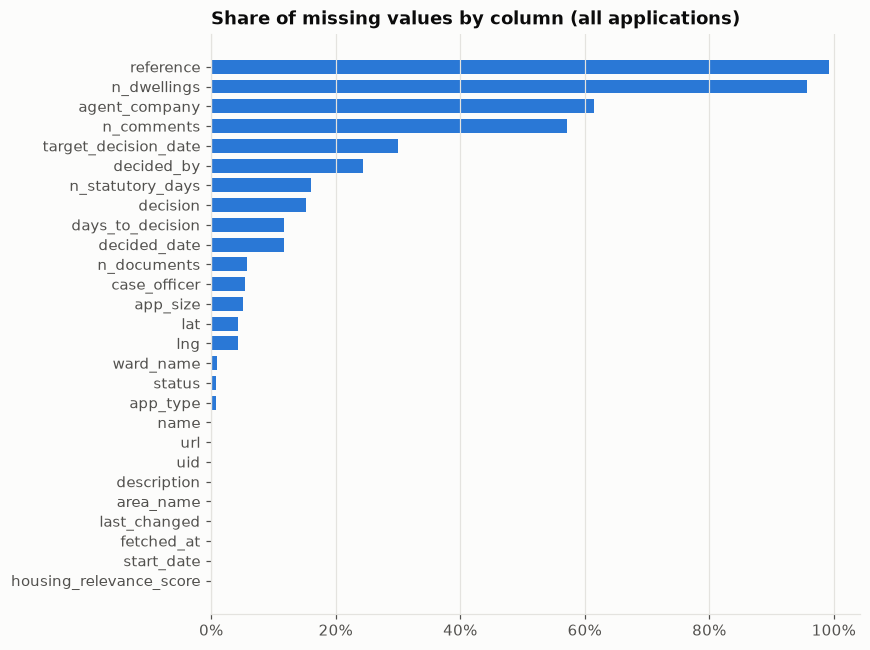

In [4]:
# Missingness across all columns
missing = data.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(missing.index[::-1], missing.values[::-1], color=APPROVED_C, height=0.7)
ax.xaxis.set_major_formatter(pct)
ax.set_title("Share of missing values by column (all applications)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

`reference`, `n_dwellings`, `agent_company` and `n_comments` are mostly empty, so they only support limited analysis. The fields that matter for the question (`area_name`, `app_type`, `status`, `days_to_decision`) are well populated.

In [5]:
# Duplicates, categorical cardinality, and the date range
print("Duplicate application names:", data["name"].duplicated().sum())
print("Fully duplicated rows:      ", data.duplicated().sum())
print("\nDistinct values:")
print(data[["area_name", "app_type", "app_size", "status", "decision", "decided_by", "ward_name"]].nunique())
print("\nStart date range:  ", data["start_date"].min(), "→", data["start_date"].max())
print("Decided date range:", data["decided_date"].min(), "→", data["decided_date"].max())

Duplicate application names: 0


Fully duplicated rows:       0

Distinct values:
area_name       35
app_type         9
app_size         3
status           7
decision       452
decided_by     104
ward_name     1214
dtype: int64

Start date range:   2022-01-01 → 2025-12-31
Decided date range: 2022-01-11 → 2026-07-31


In [6]:
print(data["app_type"].value_counts(dropna=False), "\n")
print(data["status"].value_counts(dropna=False))

app_type
Full           98512
Outline        48476
Conditions     21121
Amendment      11133
NaN             1422
Heritage         823
Other            168
Trees            127
Advertising       84
Telecoms          63
Name: count, dtype: int64 

status
Permitted     97827
Conditions    34057
Rejected      31504
Undecided      9832
Withdrawn      7198
NaN            1433
Unresolved       63
Referred         15
Name: count, dtype: int64


**Planning authorities.** The data covers the 32 London boroughs plus three authorities that aren't boroughs:
- the **City of London**
- **Old Oak & Park Royal** and **London Legacy**, both Mayoral Development Corporations

All three have very few applications. They're kept in the tables, but borough rankings and borough-level correlations only include authorities with at least 100 decided full applications.

## 2. Scoping and cleaning: full applications

In [7]:
APPROVED = {"Permitted", "Conditions"}
OUTCOME_MAP = {
    "Permitted": "Approved", "Conditions": "Approved",
    "Rejected": "Rejected", "Withdrawn": "Withdrawn",
    "Undecided": "Undecided", "Unresolved": "Undecided", "Referred": "Undecided",
}

full = data[data["app_type"] == "Full"].copy()
full["outcome"] = full["status"].map(OUTCOME_MAP).fillna("Unknown")
full["start_date"] = pd.to_datetime(full["start_date"])
full["decided_date"] = pd.to_datetime(full["decided_date"])
full["start_year"] = full["start_date"].dt.year
full["start_q"] = full["start_date"].dt.to_period("Q")


def decision_route(x):
    """Collapse ~200 free-text 'decided_by' values into a decision route."""
    if pd.isna(x):
        return "Unknown"
    s = str(x).lower()
    if "committee" in s or "members" in s:
        return "Committee"
    if "deleg" in s:
        return "Delegated"
    return "Other"


full["route"] = full["decided_by"].map(decision_route)
full["size_ord"] = full["app_size"].map({"Small": 0, "Medium": 1, "Large": 2})

print(f"Full applications: {len(full):,} ({len(full) / len(data):.0%} of all rows)")
full["outcome"].value_counts().to_frame("n").assign(share=lambda d: (d.n / d.n.sum()).round(3))

Full applications: 98,512 (54% of all rows)


,n,share
outcome,,
Approved,69122,0.702
Rejected,18680,0.190
Undecided,5878,0.060
Withdrawn,3969,0.040
Unknown,863,0.009


In [8]:
# Quality checks on decision time
dec = full[full["outcome"].isin(["Approved", "Rejected"])].copy()
dec["approved"] = (dec["outcome"] == "Approved").astype(int)

recalc = (dec["decided_date"] - dec["start_date"]).dt.days
print("days_to_decision disagrees with the recalculated dates:", int((recalc != dec["days_to_decision"]).sum() - recalc.isna().sum()))
print("Decided but no decision time:", dec["days_to_decision"].isna().sum())
print("Negative decision times:     ", (dec["days_to_decision"] < 0).sum())
print("Over 2 years:                ", (dec["days_to_decision"] > 730).sum())

# Negative durations are data errors. Very long ones are real (appeals, S106 agreements) and kept;
# medians are used so they don't dominate.
dec["valid_days"] = dec["days_to_decision"].where(dec["days_to_decision"] >= 0)

# Statutory period: 8 weeks for minor/other, 13 weeks for major (≈ Large).
# Government statistics also count agreed extensions of time as "in time", so this measure is stricter.
dec["stat_days"] = np.where(dec["app_size"] == "Large", 91, 56)
dec["in_time"] = (dec["valid_days"] <= dec["stat_days"]).astype(float).where(dec["valid_days"].notna())
print(f"\nDecided full applications used for analysis: {len(dec):,}")

days_to_decision disagrees with the recalculated dates: 0
Decided but no decision time: 4391
Negative decision times:      4
Over 2 years:                 115

Decided full applications used for analysis: 87,802


## 3. Univariate EDA

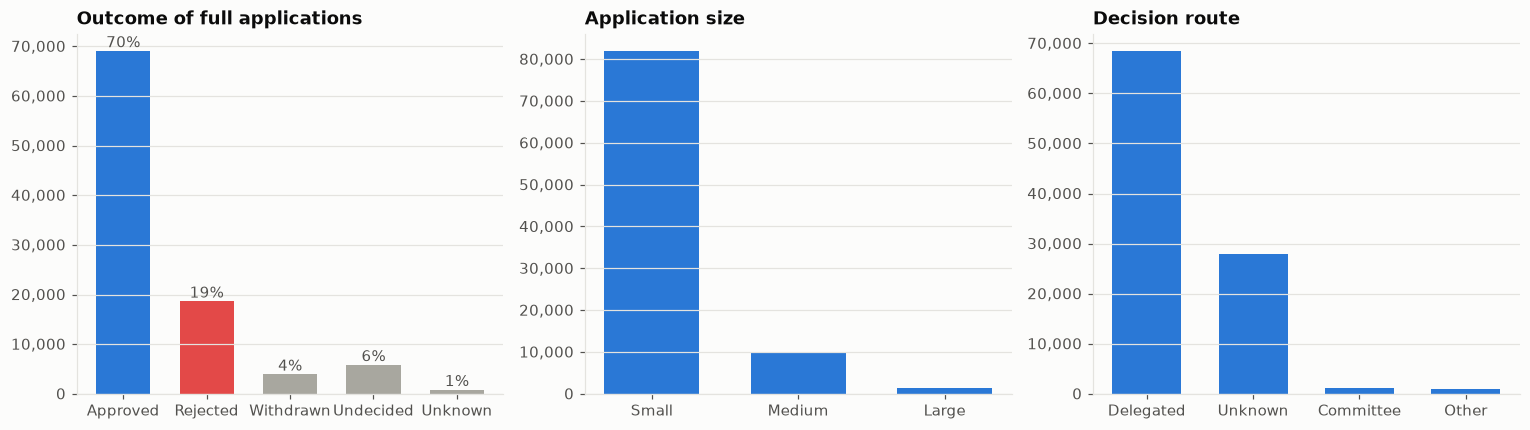

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

order = ["Approved", "Rejected", "Withdrawn", "Undecided", "Unknown"]
counts = full["outcome"].value_counts().reindex(order).fillna(0)
colors = [APPROVED_C, REJECTED_C, NEUTRAL_C, NEUTRAL_C, NEUTRAL_C]
axes[0].bar(counts.index, counts.values, color=colors, width=0.65)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v / counts.sum():.0%}", ha="center", va="bottom", color=INK_2)
axes[0].set_title("Outcome of full applications")
axes[0].grid(axis="x", visible=False)
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

size_counts = full["app_size"].value_counts().reindex(["Small", "Medium", "Large"])
axes[1].bar(size_counts.index, size_counts.values, color=APPROVED_C, width=0.65)
axes[1].set_title("Application size")
axes[1].grid(axis="x", visible=False)
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

route_counts = full["route"].value_counts()
axes[2].bar(route_counts.index, route_counts.values, color=APPROVED_C, width=0.65)
axes[2].set_title("Decision route")
axes[2].grid(axis="x", visible=False)
axes[2].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

count    83407.0
mean        87.0
std         73.1
min          0.0
5%          42.0
25%         56.0
50%         63.0
75%         90.0
95%        207.0
99%        413.0
max       1362.0
Name: valid_days, dtype: float64
Skewness: 5.04


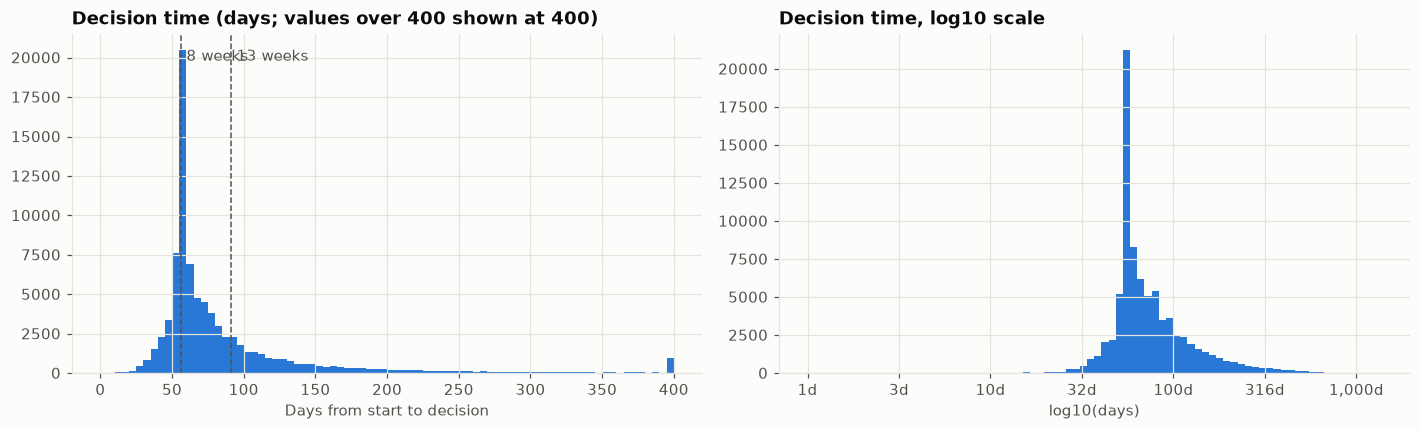

In [10]:
d = dec["valid_days"].dropna()
print(d.describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(1))
print(f"Skewness: {d.skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(d.clip(upper=400), bins=80, color=APPROVED_C)
for x, lbl in [(56, "8 weeks"), (91, "13 weeks")]:
    axes[0].axvline(x, color=INK_2, ls="--", lw=1)
    axes[0].text(x + 4, axes[0].get_ylim()[1] * 0.92, lbl, color=INK_2)
axes[0].set_title("Decision time (days; values over 400 shown at 400)")
axes[0].set_xlabel("Days from start to decision")

axes[1].hist(np.log10(d[d > 0]), bins=80, color=APPROVED_C)
axes[1].set_title("Decision time, log10 scale")
axes[1].set_xlabel("log10(days)")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{10 ** v:,.0f}d"))
plt.tight_layout()
plt.show()

Decision times are strongly right-skewed. Most full applications cluster just before the 8-week statutory deadline, and there's a long tail stretching past a year. This is why the analysis uses **medians and rank-based (Spearman / Mann-Whitney / Kruskal-Wallis) statistics** rather than means and Pearson correlations.

                           count    mean     std   min    50%    90%    99%     max
n_documents              83251.0   14.10   18.21   0.0  11.00   23.0   59.0  2047.0
n_comments               32271.0    2.16   20.74   0.0   0.00    3.0   31.3  1978.0
n_dwellings                823.0  165.22  253.21  10.0  59.00  449.0  839.0  2550.0
housing_relevance_score  87802.0    0.97    0.03   0.9   0.98    1.0    1.0     1.0


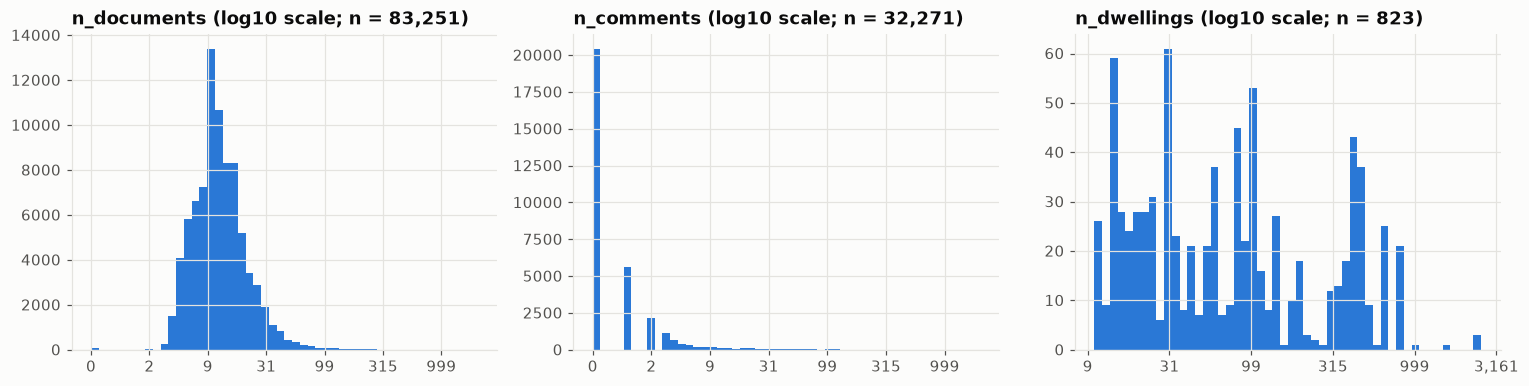

In [11]:
# Other numeric fields for decided full applications
num_cols = ["n_documents", "n_comments", "n_dwellings", "housing_relevance_score"]
print(dec[num_cols].describe(percentiles=[.5, .9, .99]).T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, c in zip(axes, ["n_documents", "n_comments", "n_dwellings"]):
    v = dec[c].dropna()
    ax.hist(np.log10(v + 1), bins=50, color=APPROVED_C)
    ax.set_title(f"{c} (log10 scale; n = {len(v):,})")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{10 ** x - 1:,.0f}"))
plt.tight_layout()
plt.show()

## 4. Approval and rejection rates by borough

In [12]:
def wilson_ci(k, n, z=1.96):
    """95% Wilson score interval for a binomial proportion."""
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


MIN_DECIDED = 100

outcome_counts = pd.crosstab(full["area_name"], full["outcome"])
borough = pd.DataFrame({
    "total_full": outcome_counts.sum(axis=1),
    "approved": outcome_counts.get("Approved", 0),
    "rejected": outcome_counts.get("Rejected", 0),
    "withdrawn": outcome_counts.get("Withdrawn", 0),
    "undecided": outcome_counts.get("Undecided", 0),
})
borough["decided"] = borough["approved"] + borough["rejected"]
borough["approval_rate"] = borough["approved"] / borough["decided"]
borough["rejection_rate"] = 1 - borough["approval_rate"]
borough["withdrawal_rate"] = borough["withdrawn"] / borough["total_full"]
borough["ci_low"], borough["ci_high"] = wilson_ci(borough["approved"], borough["decided"])
borough["reliable"] = borough["decided"] >= MIN_DECIDED
borough = borough.sort_values("approval_rate", ascending=False)

LONDON_APPROVAL = borough["approved"].sum() / borough["decided"].sum()
print(f"London-wide approval rate: {LONDON_APPROVAL:.1%}   rejection rate: {1 - LONDON_APPROVAL:.1%}")
print("Excluded from rankings (< 100 decided):", list(borough.index[~borough["reliable"]]))

(borough[["total_full", "decided", "approval_rate", "rejection_rate", "ci_low", "ci_high", "withdrawal_rate"]]
 .style.format({"approval_rate": "{:.1%}", "rejection_rate": "{:.1%}", "ci_low": "{:.1%}",
                "ci_high": "{:.1%}", "withdrawal_rate": "{:.1%}", "total_full": "{:,}", "decided": "{:,}"})
 .background_gradient(subset=["approval_rate"], cmap=SEQUENTIAL))

London-wide approval rate: 78.7%   rejection rate: 21.3%
Excluded from rankings (< 100 decided): ['City', 'London Legacy', 'Old Oak Park Royal']


,total_full,decided,approval_rate,rejection_rate,ci_low,ci_high,withdrawal_rate
area_name,,,,,,,
City,110,79,100.0%,0.0%,95.4%,100.0%,2.7%
Hammersmith and Fulham,"2,656","2,375",94.2%,5.8%,93.2%,95.1%,5.3%
Wandsworth,"5,582","5,228",93.4%,6.6%,92.7%,94.1%,4.8%
Southwark,"1,651","1,331",91.7%,8.3%,90.1%,93.0%,2.6%
London Legacy,58,47,89.4%,10.6%,77.4%,95.4%,10.3%
Camden,"1,612","1,388",87.6%,12.4%,85.8%,89.2%,9.0%
Westminster,"1,087",546,87.2%,12.8%,84.1%,89.7%,5.5%
Kensington,756,617,86.7%,13.3%,83.8%,89.2%,16.0%
Bexley,"3,933","2,685",86.7%,13.3%,85.3%,87.9%,1.0%


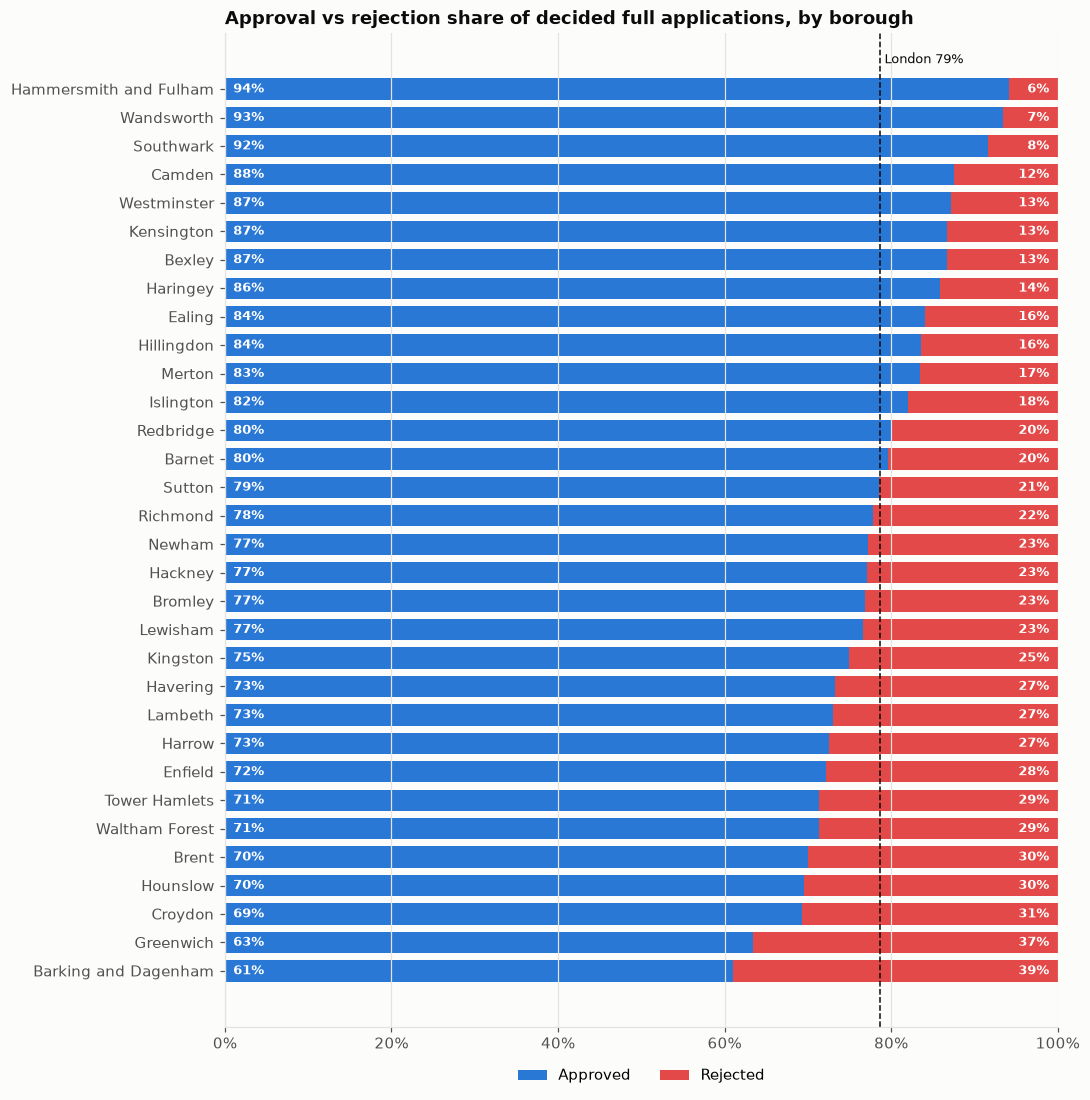

In [13]:
b = borough[borough["reliable"]].sort_values("approval_rate")
fig, ax = plt.subplots(figsize=(10, 10))
y = np.arange(len(b))
ax.barh(y, b["approval_rate"], color=APPROVED_C, height=0.75, label="Approved")
ax.barh(y, b["rejection_rate"], left=b["approval_rate"], color=REJECTED_C, height=0.75, label="Rejected")
for yi, (a, r) in enumerate(zip(b["approval_rate"], b["rejection_rate"])):
    ax.text(0.01, yi, f"{a:.0%}", va="center", color="white", fontsize=8.5, fontweight="bold")
    ax.text(0.99, yi, f"{r:.0%}", va="center", ha="right", color="white", fontsize=8.5, fontweight="bold")
ax.axvline(LONDON_APPROVAL, color=INK, lw=1, ls="--")
ax.text(LONDON_APPROVAL, len(b) - 0.2, f" London {LONDON_APPROVAL:.0%}", color=INK, va="bottom", fontsize=8.5)
ax.set_yticks(y, b.index)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis="y", visible=False)
ax.set_title("Approval vs rejection share of decided full applications, by borough")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.07), ncol=2)
plt.tight_layout()
plt.show()

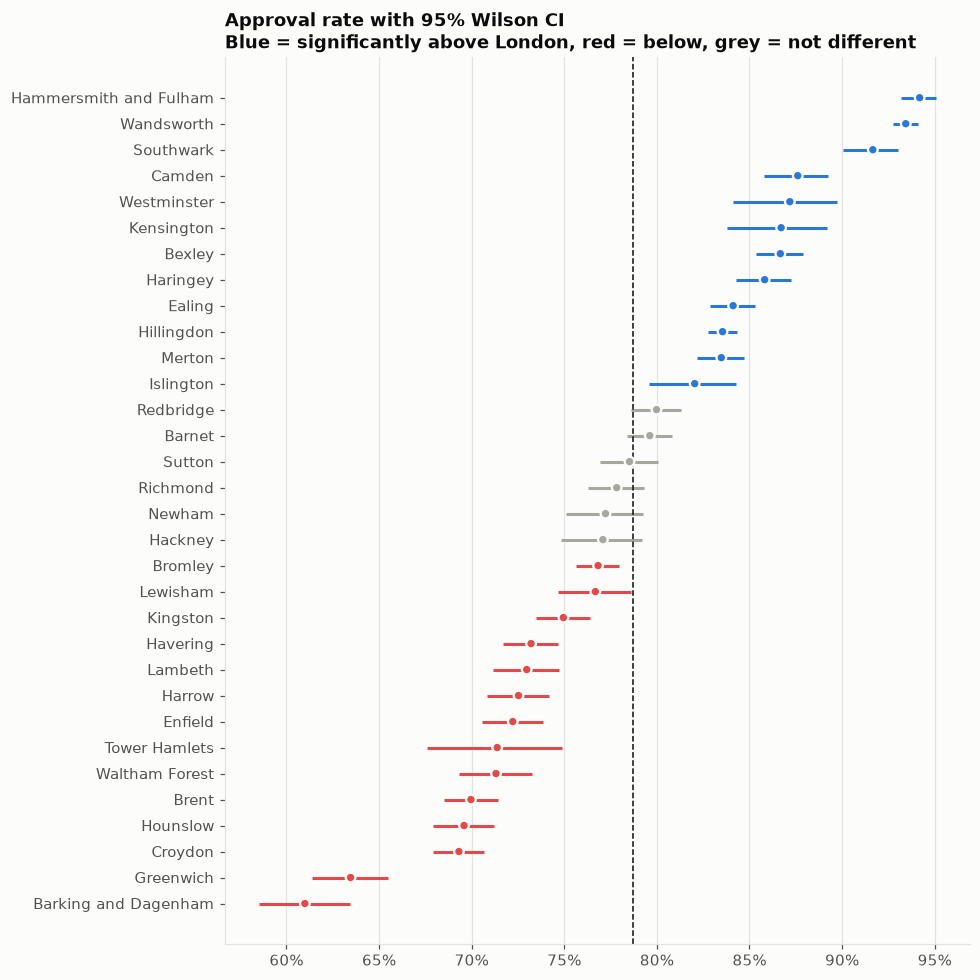

Significantly above London: 12, below: 14, not different: 6


In [14]:
# Approval rate with 95% confidence intervals: which boroughs actually differ from London?
b = borough[borough["reliable"]].sort_values("approval_rate")
fig, ax = plt.subplots(figsize=(9, 9))
y = np.arange(len(b))
sig_hi = b["ci_low"] > LONDON_APPROVAL
sig_lo = b["ci_high"] < LONDON_APPROVAL
col = np.where(sig_hi, APPROVED_C, np.where(sig_lo, REJECTED_C, NEUTRAL_C))
ax.hlines(y, b["ci_low"], b["ci_high"], color=col, lw=2)
ax.scatter(b["approval_rate"], y, color=col, s=40, zorder=3, edgecolor="#fcfcfb", linewidth=1.5)
ax.axvline(LONDON_APPROVAL, color=INK, lw=1, ls="--")
ax.set_yticks(y, b.index)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis="y", visible=False)
ax.set_title("Approval rate with 95% Wilson CI\nBlue = significantly above London, red = below, grey = not different")
plt.tight_layout()
plt.show()
print(f"Significantly above London: {sig_hi.sum()}, below: {sig_lo.sum()}, not different: {(~sig_hi & ~sig_lo).sum()}")

In [15]:
# Does approval depend on application size, and is the borough ranking just a mix effect?
size_rates = (dec.groupby("app_size")["approved"].agg(["mean", "size"])
              .reindex(["Small", "Medium", "Large"]).rename(columns={"mean": "approval_rate", "size": "n"}))
print(size_rates.round(3))

small_only = dec[dec["app_size"] == "Small"].groupby("area_name")["approved"].mean()
comp = borough.loc[borough["reliable"], ["approval_rate"]].join(small_only.rename("approval_small_only"))
rho, p = stats.spearmanr(comp["approval_rate"], comp["approval_small_only"])
print(f"\nBorough ranking, all sizes vs Small-only: Spearman ρ = {rho:.2f} (p = {p:.1e})")

          approval_rate      n
app_size                      
Small             0.780  73389
Medium            0.869   9259
Large             0.891    929



Borough ranking, all sizes vs Small-only: Spearman ρ = 0.96 (p = 2.2e-18)


If the ranking holds up when only **Small** applications are counted, the borough differences aren't just caused by some boroughs receiving more large schemes.

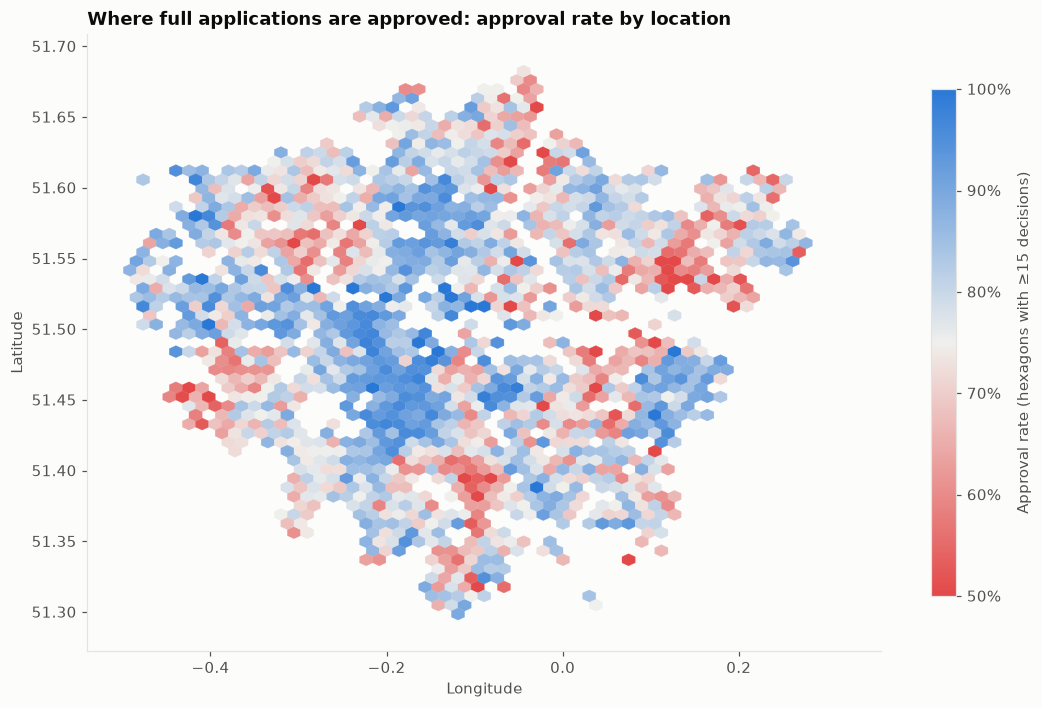

In [16]:
# Geographic view: mean approval rate per hexagon (London bounding box)
geo = dec[dec["lat"].between(51.28, 51.70) & dec["lng"].between(-0.52, 0.34)]
fig, ax = plt.subplots(figsize=(10, 7))
hb = ax.hexbin(geo["lng"], geo["lat"], C=geo["approved"], reduce_C_function=np.mean,
               gridsize=55, cmap=DIVERGING, vmin=0.5, vmax=1.0, mincnt=15, linewidths=0.2)
cb = fig.colorbar(hb, ax=ax, shrink=0.7, format=pct)
cb.set_label("Approval rate (hexagons with ≥15 decisions)")
ax.set_aspect(1 / np.cos(np.radians(51.5)))
ax.set_title("Where full applications are approved: approval rate by location")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(False)
plt.tight_layout()
plt.show()

## 5. Time to reach a decision, by borough

In [17]:
valid = dec[dec["valid_days"].notna()]
time_b = valid.groupby("area_name").agg(
    n=("valid_days", "size"),
    median_days=("valid_days", "median"),
    q1=("valid_days", lambda s: s.quantile(.25)),
    q3=("valid_days", lambda s: s.quantile(.75)),
    p90=("valid_days", lambda s: s.quantile(.90)),
    mean_days=("valid_days", "mean"),
    in_time=("in_time", "mean"),
)
time_b["iqr"] = time_b["q3"] - time_b["q1"]
med_by_outcome = valid.pivot_table(index="area_name", columns="outcome", values="valid_days", aggfunc="median")
time_b["median_approved"] = med_by_outcome["Approved"]
time_b["median_rejected"] = med_by_outcome["Rejected"]
borough = borough.join(time_b.drop(columns="n"))

LONDON_MEDIAN = valid["valid_days"].median()
LONDON_IN_TIME = valid["in_time"].mean()
print(f"London median decision time: {LONDON_MEDIAN:.0f} days; decided within statutory period: {LONDON_IN_TIME:.1%}")

(borough.loc[borough["reliable"], ["median_days", "q1", "q3", "p90", "mean_days", "in_time", "median_approved", "median_rejected"]]
 .sort_values("median_days")
 .style.format("{:.0f}").format({"in_time": "{:.1%}"})
 .background_gradient(subset=["median_days"], cmap=SEQUENTIAL))

London median decision time: 63 days; decided within statutory period: 38.3%


,median_days,q1,q3,p90,mean_days,in_time,median_approved,median_rejected
area_name,,,,,,,,
Barking and Dagenham,51.000000,45.000000,55.000000,70.000000,54.529412,79.4%,51.000000,52.000000
Redbridge,56.000000,46.000000,76.000000,110.400000,69.220870,50.7%,56.000000,63.000000
Newham,56.000000,53.000000,69.000000,103.000000,71.279924,61.1%,56.000000,56.000000
Hillingdon,56.000000,52.000000,77.000000,121.000000,73.938002,54.6%,56.000000,57.000000
Tower Hamlets,56.000000,54.000000,90.000000,188.800000,95.296422,58.1%,56.000000,56.000000
Bexley,57.000000,55.000000,71.000000,105.000000,71.922533,49.5%,56.000000,60.500000
Barnet,58.000000,56.000000,82.000000,140.000000,83.964432,41.8%,58.000000,58.000000
Haringey,58.000000,56.000000,92.000000,154.000000,88.239090,47.7%,59.000000,56.000000
Southwark,59.000000,50.000000,78.500000,120.000000,78.371150,44.5%,58.000000,70.000000


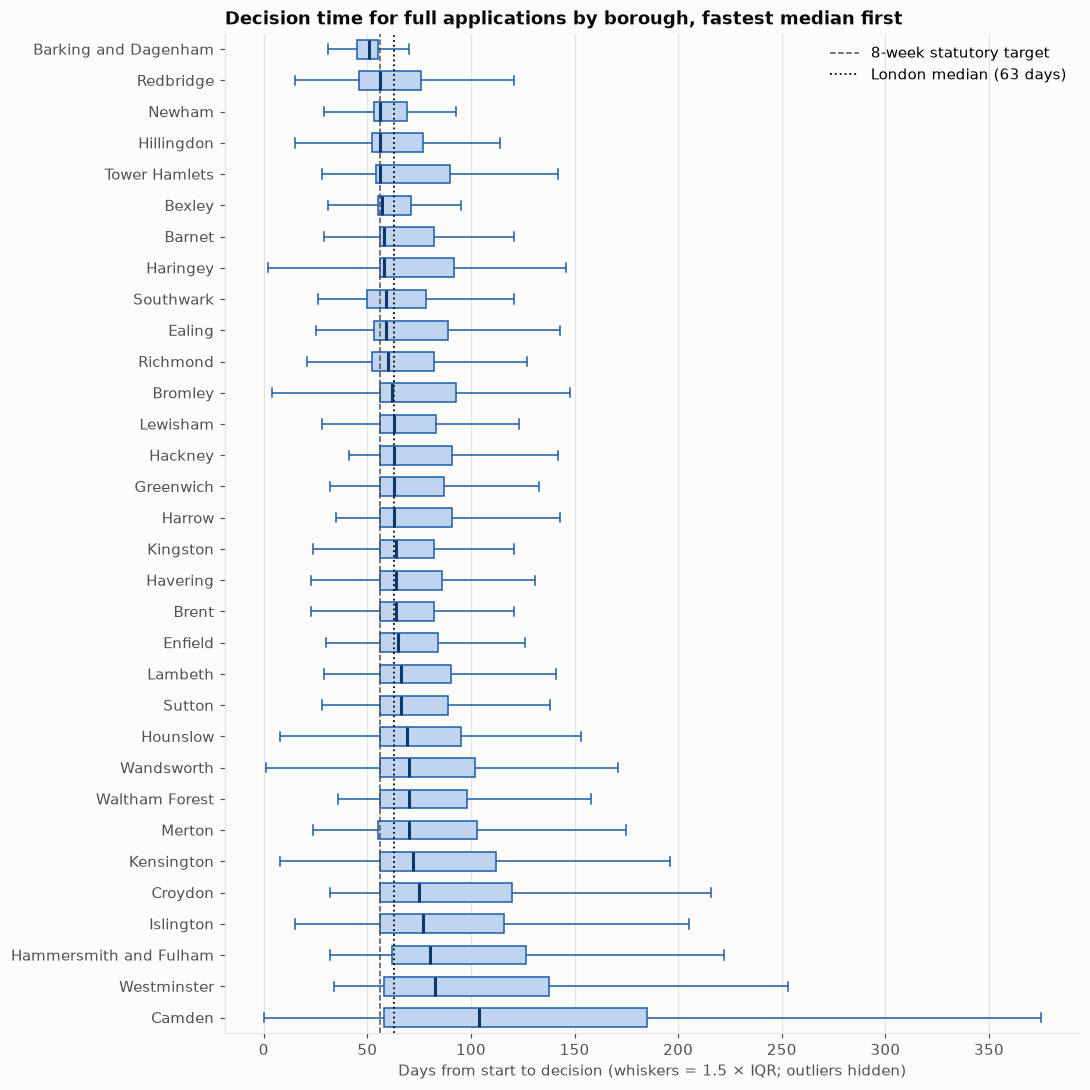

In [18]:
rel = borough.index[borough["reliable"]]
order_b = time_b.loc[rel].sort_values("median_days").index
plot_df = valid[valid["area_name"].isin(rel)]

fig, ax = plt.subplots(figsize=(10, 10))
sns.boxplot(data=plot_df, y="area_name", x="valid_days", order=order_b, showfliers=False,
            color="#b7d3f6", linecolor="#1c5cab", linewidth=1, width=0.6, ax=ax,
            medianprops={"color": "#0d366b", "linewidth": 2})
ax.axvline(56, color=INK_2, ls="--", lw=1, label="8-week statutory target")
ax.axvline(LONDON_MEDIAN, color=INK, ls=":", lw=1.2, label=f"London median ({LONDON_MEDIAN:.0f} days)")
ax.legend(loc="upper right")
ax.set_xlabel("Days from start to decision (whiskers = 1.5 × IQR; outliers hidden)")
ax.set_ylabel("")
ax.set_title("Decision time for full applications by borough, fastest median first")
plt.tight_layout()
plt.show()

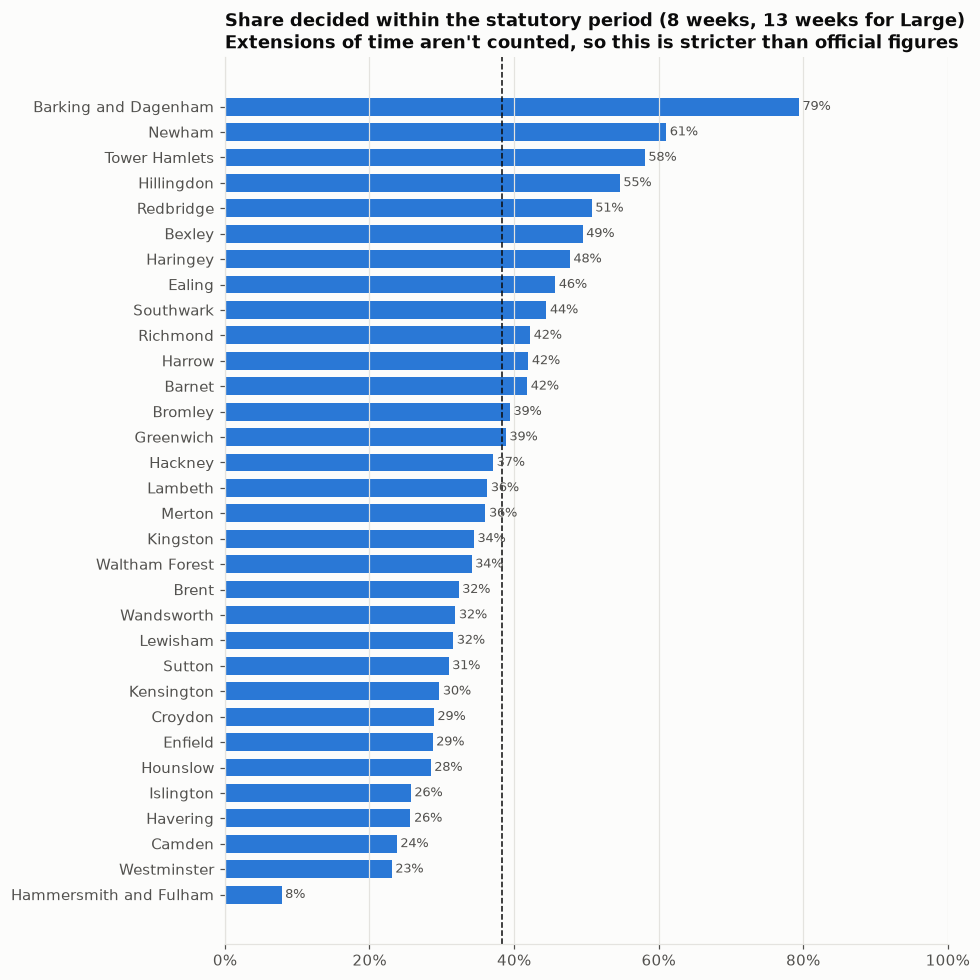

In [19]:
b = borough[borough["reliable"]].sort_values("in_time")
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(b.index, b["in_time"], color=APPROVED_C, height=0.7)
for yi, v in enumerate(b["in_time"]):
    ax.text(v + 0.005, yi, f"{v:.0%}", va="center", color=INK_2, fontsize=8.5)
ax.axvline(LONDON_IN_TIME, color=INK, ls="--", lw=1)
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Share decided within the statutory period (8 weeks, 13 weeks for Large)\nExtensions of time aren't counted, so this is stricter than official figures")
plt.tight_layout()
plt.show()

Median days: approved 63, rejected 64
Mann-Whitney U p = 2.29e-31, rank-biserial r = 0.057 (positive → rejected take longer)


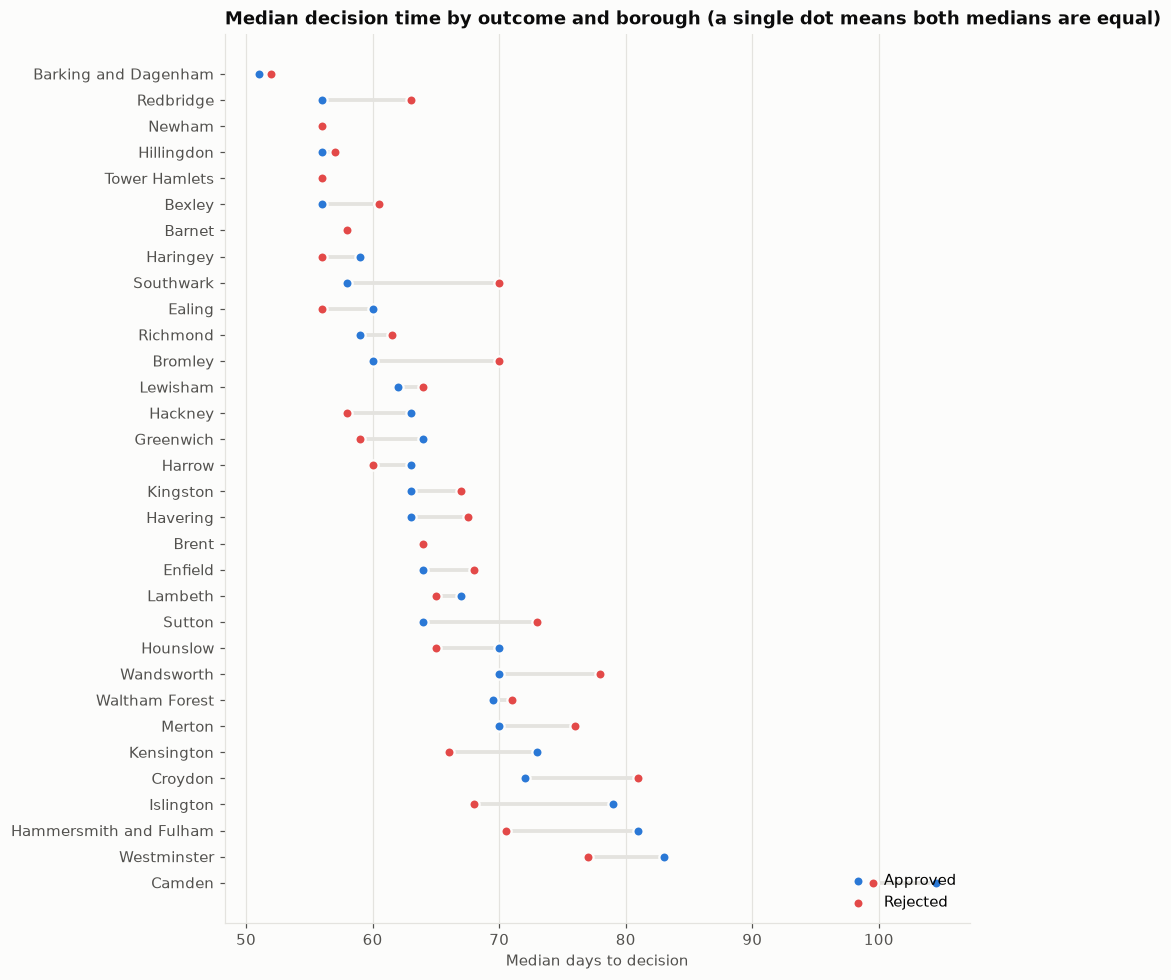

In [20]:
# Are refusals decided faster or slower than approvals?
a_days = valid.loc[valid["outcome"] == "Approved", "valid_days"]
r_days = valid.loc[valid["outcome"] == "Rejected", "valid_days"]
U, p = stats.mannwhitneyu(a_days, r_days, alternative="two-sided")
rank_biserial = 1 - 2 * U / (len(a_days) * len(r_days))
print(f"Median days: approved {a_days.median():.0f}, rejected {r_days.median():.0f}")
print(f"Mann-Whitney U p = {p:.2e}, rank-biserial r = {rank_biserial:.3f} (positive → rejected take longer)")

b = borough[borough["reliable"]].sort_values("median_days")
fig, ax = plt.subplots(figsize=(9, 9))
y = np.arange(len(b))
ax.hlines(y, b["median_approved"], b["median_rejected"], color=GRID, lw=2.5)
ax.scatter(b["median_approved"], y, color=APPROVED_C, s=45, zorder=3, label="Approved", edgecolor="#fcfcfb", linewidth=1.5)
ax.scatter(b["median_rejected"], y, color=REJECTED_C, s=45, zorder=3, label="Rejected", edgecolor="#fcfcfb", linewidth=1.5)
ax.set_yticks(y, b.index)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Median days to decision")
ax.invert_yaxis()  # fastest first, matching the box plot
ax.set_title("Median decision time by outcome and borough (a single dot means both medians are equal)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [21]:
# Decision time by size and route
print(valid.groupby("app_size")["valid_days"].describe(percentiles=[.5]).round(0).reindex(["Small", "Medium", "Large"]))
print(valid.groupby("route")["valid_days"].describe(percentiles=[.5]).round(0))

            count   mean    std  min    50%     max
app_size                                           
Small     73222.0   80.0   61.0  0.0   60.0  1194.0
Medium     9248.0  125.0   99.0  0.0   92.0  1344.0
Large       921.0  236.0  213.0  4.0  171.0  1362.0
             count   mean    std   min    50%     max
route                                                
Committee   1063.0  255.0  187.0  28.0  204.0  1362.0
Delegated  64509.0   85.0   65.0   0.0   63.0  1194.0
Other        254.0  143.0  146.0  28.0   96.0  1078.0
Unknown    17581.0   85.0   74.0   0.0   61.0  1344.0


## 6. Trends over time

The dataset only contains applications **started** from 2022 onwards, so results are grouped by start quarter (cohort). Recent cohorts are *right-censored*: slow applications that are still undecided are missing, which makes recent cohorts look faster than they really are. Shaded quarters have more than 10% of applications still undecided.

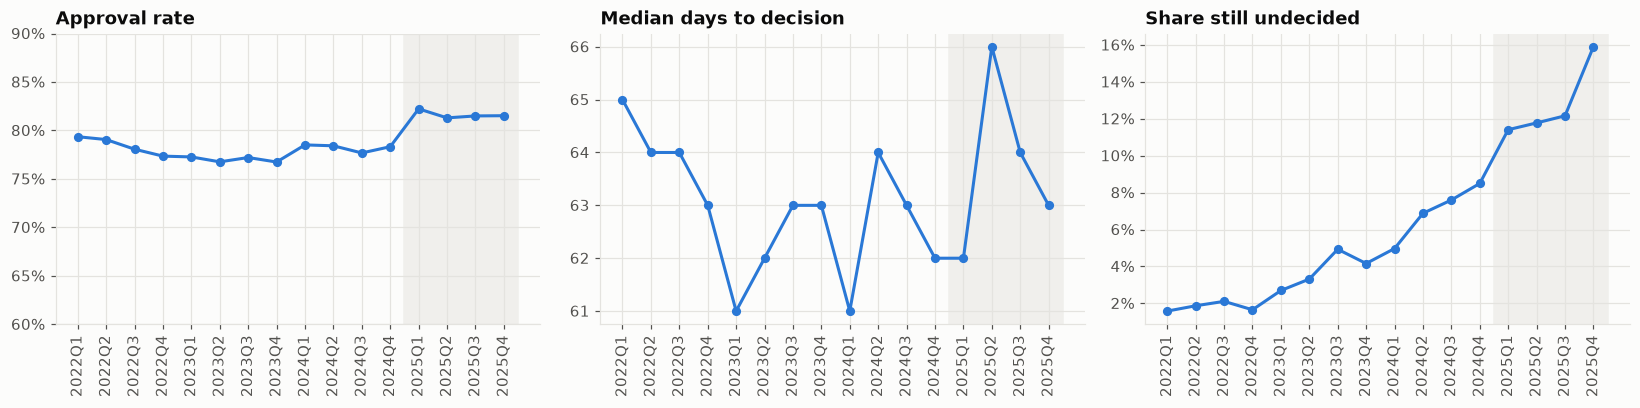

,n,undecided,approval_rate,median_days,in_time
start_q,,,,,
2022Q1,7845,0.016,0.794,65.0,0.369
2022Q2,7600,0.019,0.791,64.0,0.364
2022Q3,6738,0.021,0.781,64.0,0.366
2022Q4,6298,0.017,0.774,63.0,0.382
2023Q1,6712,0.027,0.773,61.0,0.399
2023Q2,6366,0.033,0.768,62.0,0.410
2023Q3,5923,0.049,0.772,63.0,0.401
2023Q4,5771,0.042,0.767,63.0,0.384
2024Q1,5836,0.050,0.785,61.0,0.412


In [22]:
cohort = full.groupby("start_q").agg(n=("outcome", "size"), undecided=("outcome", lambda s: (s == "Undecided").mean()))
cohort = cohort.join(dec.groupby("start_q").agg(approval_rate=("approved", "mean"),
                                                median_days=("valid_days", "median"),
                                                in_time=("in_time", "mean")))
x = cohort.index.astype(str)
censored = cohort["undecided"] > 0.10

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharex=True)
for ax, col_, title, fmt in [
    (axes[0], "approval_rate", "Approval rate", pct),
    (axes[1], "median_days", "Median days to decision", None),
    (axes[2], "undecided", "Share still undecided", pct),
]:
    ax.plot(x, cohort[col_], color=APPROVED_C, lw=2, marker="o", ms=5)
    for xi in np.where(censored)[0]:
        ax.axvspan(xi - 0.5, xi + 0.5, color="#f0efec", zorder=0)
    ax.set_title(title)
    if fmt:
        ax.yaxis.set_major_formatter(fmt)
    ax.tick_params(axis="x", rotation=90)
axes[0].set_ylim(0.6, 0.9)
plt.tight_layout()
plt.show()
cohort.round(3)

## 7. Correlational analysis

### 7a. Application level: numeric and binary variables (Spearman)
The unit here is one decided full application. Spearman's ρ is used because the variables are skewed or ordinal. `approved`, `committee` and `size_ord` are binary or ordinal codes, so ρ against them is a rank-based measure of association. Correlations are computed pairwise, so each pair uses the rows where both values exist (`n_dwellings` and `n_comments` are sparse).

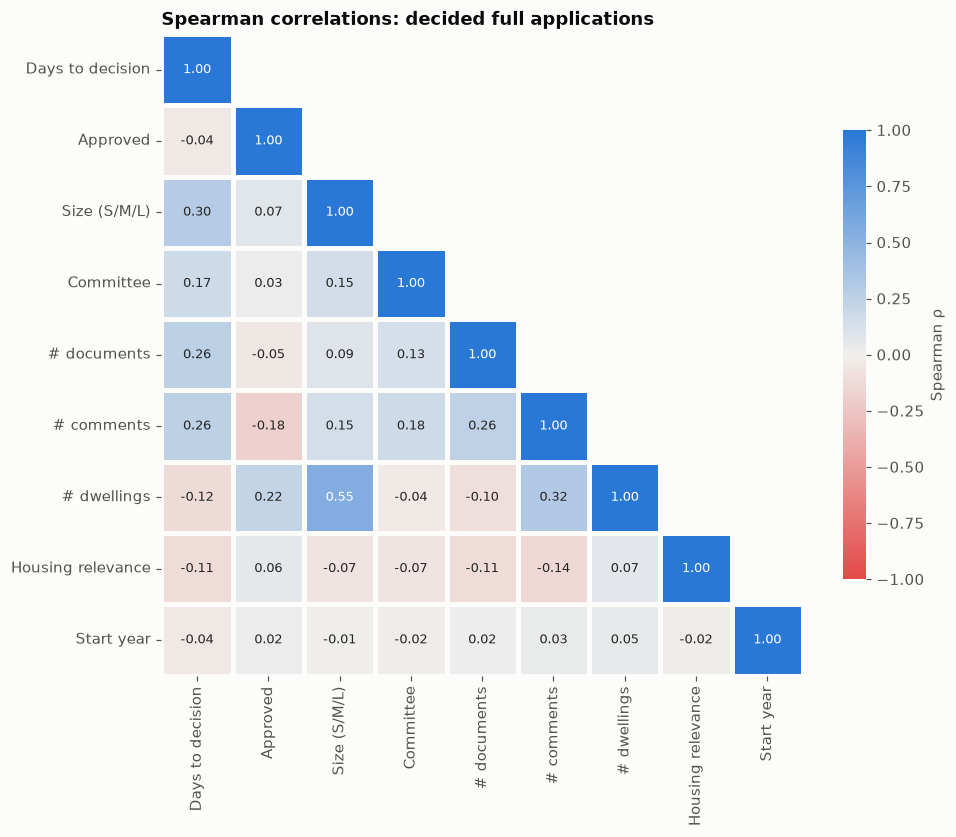

In [23]:
app = dec.assign(
    committee=(dec["route"] == "Committee").astype(float).where(dec["route"] != "Unknown"),
    start_year=dec["start_year"].astype(float),
)
corr_vars = ["valid_days", "approved", "size_ord", "committee", "n_documents", "n_comments",
             "n_dwellings", "housing_relevance_score", "start_year"]
labels = ["Days to decision", "Approved", "Size (S/M/L)", "Committee", "# documents", "# comments",
          "# dwellings", "Housing relevance", "Start year"]

rho = app[corr_vars].corr(method="spearman")
nobs = app[corr_vars].notna().astype(int).T @ app[corr_vars].notna().astype(int)

mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(rho, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8.5}, linewidths=2, linecolor="#fcfcfb", square=True,
            xticklabels=labels, yticklabels=labels, cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=ax)
ax.grid(False)
ax.set_title("Spearman correlations: decided full applications")
plt.tight_layout()
plt.show()

In [24]:
# Correlations with the two targets, including p-values and n
def spearman_table(df, target, others):
    rows = []
    for c in others:
        sub = df[[target, c]].dropna()
        r, p = stats.spearmanr(sub[target], sub[c])
        rows.append({"variable": c, "rho": r, "p_value": p, "n": len(sub)})
    return pd.DataFrame(rows).set_index("variable").sort_values("rho", key=abs, ascending=False)

print("Association with DAYS TO DECISION")
print(spearman_table(app, "valid_days", [v for v in corr_vars if v != "valid_days"]).round(4), "\n")
print("Association with APPROVED (1) vs REJECTED (0)")
print(spearman_table(app, "approved", [v for v in corr_vars if v != "approved"]).round(4))

Association with DAYS TO DECISION


                            rho  p_value      n
variable                                       
size_ord                 0.2954   0.0000  83391
n_comments               0.2643   0.0000  32269
n_documents              0.2586   0.0000  83072
committee                0.1744   0.0000  65826
n_dwellings             -0.1246   0.0004    812
housing_relevance_score -0.1147   0.0000  83407
start_year              -0.0413   0.0000  83407
approved                -0.0403   0.0000  83407 

Association with APPROVED (1) vs REJECTED (0)


                            rho  p_value      n
variable                                       
n_dwellings              0.2217      0.0    823
n_comments              -0.1810      0.0  32271
size_ord                 0.0736      0.0  83577
housing_relevance_score  0.0604      0.0  87802
n_documents             -0.0527      0.0  83251
valid_days              -0.0403      0.0  83407
committee                0.0253      0.0  65874
start_year               0.0241      0.0  87802


With around 80,000 observations almost every correlation is "statistically significant", so **judge them by size**. As a rough guide, |ρ| < 0.1 is negligible, 0.1–0.3 weak, 0.3–0.5 moderate and above 0.5 strong.

### 7b. Categorical associations with the outcome (χ² and Cramér's V) and with decision time (Kruskal-Wallis, ε²)

In [25]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    # Bias-corrected Cramér's V (Bergsma 2013)
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / min(kc - 1, rc - 1)), chi2, p, dof


def kruskal_eps2(df, group, value):
    groups = [g[value].dropna().values for _, g in df.groupby(group) if g[value].notna().sum() > 0]
    H, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    return (H - len(groups) + 1) / (n - len(groups)), H, p


cat_rows = []
dec_rel = dec[dec["area_name"].isin(rel)]
for name, col_ in [("Borough", "area_name"), ("Application size", "app_size"),
                   ("Decision route", "route"), ("Start year", "start_year")]:
    sub = dec_rel[[col_, "approved", "valid_days"]].dropna(subset=[col_])
    v, chi2, p, dof = cramers_v(sub[col_], sub["approved"])
    eps2, H, pk = kruskal_eps2(sub, col_, "valid_days")
    cat_rows.append({"factor": name, "Cramér's V (vs outcome)": v, "χ² p": p,
                     "ε² (vs days)": eps2, "Kruskal p": pk, "levels": sub[col_].nunique()})
pd.DataFrame(cat_rows).set_index("factor").round(4)

,Cramér's V (vs outcome),χ² p,ε² (vs days),Kruskal p,levels
factor,,,,,
Borough,0.1892,0.0,0.0650,0.0,32
Application size,0.0732,0.0,0.0864,0.0,3
Decision route,0.0225,0.0,0.0252,0.0,4
Start year,0.0395,0.0,0.0029,0.0,4


In [26]:
# Approval rate and median time by decision route: are committee decisions different?
route_tbl = dec.groupby("route").agg(n=("approved", "size"), approval_rate=("approved", "mean"),
                                     median_days=("valid_days", "median"))
route_tbl.style.format({"n": "{:,}", "approval_rate": "{:.1%}", "median_days": "{:.0f}"})

,n,approval_rate,median_days
route,,,
Committee,"1,064",86.7%,204
Delegated,"64,555",78.4%,63
Other,255,75.3%,96
Unknown,"21,928",79.3%,61


### 7c. Borough level: do faster boroughs approve more?
Here the unit is a borough (n ≈ 32), so power is limited and p-values matter more. For each borough the variables are its approval rate, speed, workload and application mix.

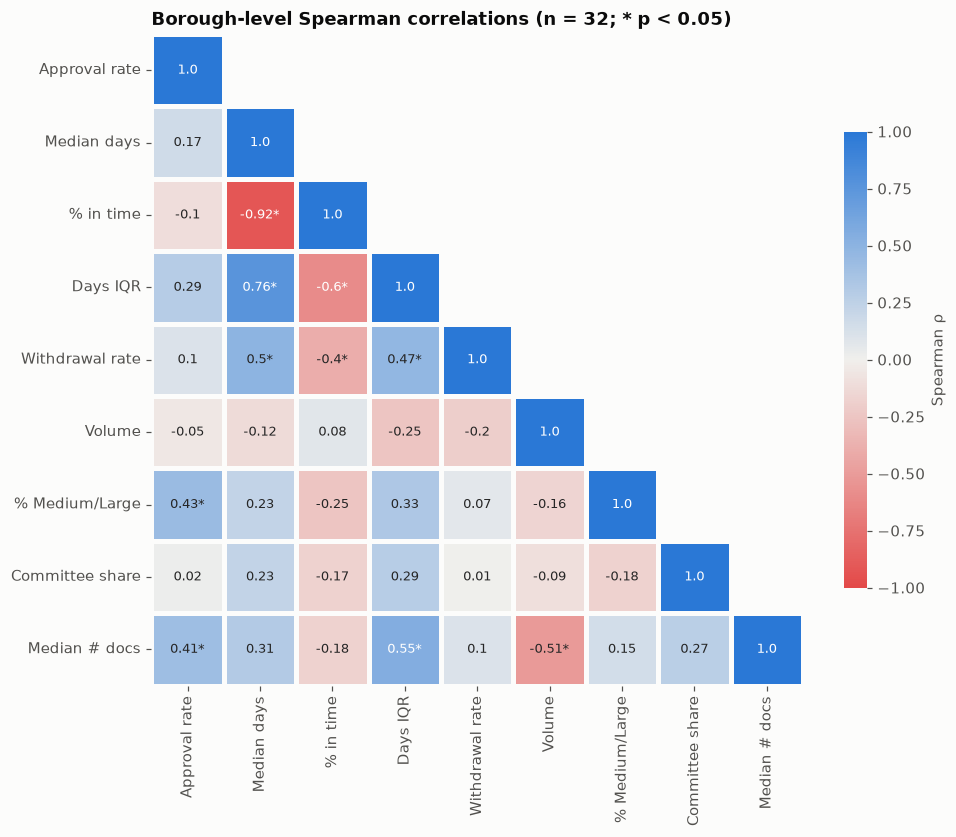

In [27]:
mix = dec.groupby("area_name").agg(
    share_medium_large=("size_ord", lambda s: (s >= 1).mean()),
    committee_share=("route", lambda s: (s == "Committee").mean()),
    median_documents=("n_documents", "median"),
)
bl = borough.loc[borough["reliable"]].join(mix)
bl["volume"] = bl["total_full"]
bvars = ["approval_rate", "median_days", "in_time", "iqr", "withdrawal_rate", "volume",
         "share_medium_large", "committee_share", "median_documents"]
blabels = ["Approval rate", "Median days", "% in time", "Days IQR", "Withdrawal rate", "Volume",
           "% Medium/Large", "Committee share", "Median # docs"]

brho = bl[bvars].corr(method="spearman")
bp = pd.DataFrame(np.ones_like(brho), index=bvars, columns=bvars)
for i in bvars:
    for j in bvars:
        if i != j:
            pair = bl[[i, j]].dropna()
            bp.loc[i, j] = stats.spearmanr(pair[i], pair[j]).pvalue
annot = brho.round(2).astype(str) + np.where(bp < 0.05, "*", "")

mask = np.triu(np.ones_like(brho, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(brho, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=annot, fmt="",
            annot_kws={"size": 8.5}, linewidths=2, linecolor="#fcfcfb", square=True,
            xticklabels=blabels, yticklabels=blabels, cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=ax)
ax.grid(False)
ax.set_title(f"Borough-level Spearman correlations (n = {len(bl)}; * p < 0.05)")
plt.tight_layout()
plt.show()

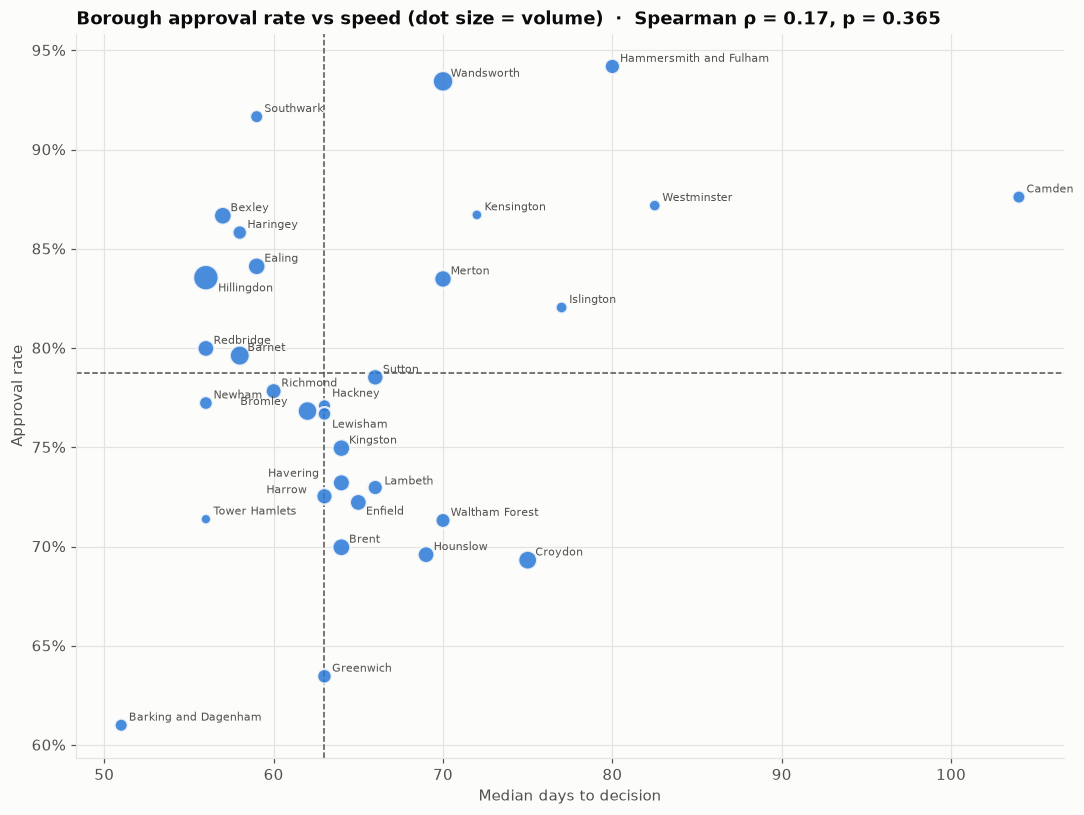

In [28]:
r, p = stats.spearmanr(bl["median_days"], bl["approval_rate"])
fig, ax = plt.subplots(figsize=(10, 7.5))
sizes = 30 + 250 * bl["volume"] / bl["volume"].max()
ax.scatter(bl["median_days"], bl["approval_rate"], s=sizes, color=APPROVED_C, alpha=0.85,
           edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
nudge = {"Hackney": (5, 6), "Lewisham": (5, -9), "Bromley": (-44, 4), "Harrow": (-38, 2),
         "Enfield": (5, -8), "Havering": (-48, 4), "Lambeth": (6, 2), "Hillingdon": (8, -9)}
for name, row in bl.iterrows():
    ax.annotate(name, (row["median_days"], row["approval_rate"]), xytext=nudge.get(name, (5, 3)),
                textcoords="offset points", fontsize=7.5, color=INK_2)
ax.axhline(LONDON_APPROVAL, color=INK_2, ls="--", lw=1)
ax.axvline(LONDON_MEDIAN, color=INK_2, ls="--", lw=1)
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Median days to decision")
ax.set_ylabel("Approval rate")
ax.set_title(f"Borough approval rate vs speed (dot size = volume)  ·  Spearman ρ = {r:.2f}, p = {p:.3f}")
plt.tight_layout()
plt.show()

## 8. Key findings

The cell below recomputes the headline numbers. The interpretation after it was written from this run of the data; if the data is refreshed, check the text against the printed numbers.

In [29]:
b = borough[borough["reliable"]]
top = b["approval_rate"].nlargest(3)
bot = b["approval_rate"].nsmallest(3)
fast = b["median_days"].nsmallest(3)
slow = b["median_days"].nlargest(3)
r_speed, p_speed = stats.spearmanr(b["median_days"], b["approval_rate"])

print(f"""KEY NUMBERS: full planning applications, London, started 2022–2025
- {len(full):,} full applications; {len(dec):,} decided (approved or rejected).
- London-wide: {LONDON_APPROVAL:.1%} approved, {1 - LONDON_APPROVAL:.1%} rejected.
- Borough approval range: {b['approval_rate'].min():.1%} to {b['approval_rate'].max():.1%} (a gap of {b['approval_rate'].max() - b['approval_rate'].min():.0%} points).
    Highest: {', '.join(f'{k} {v:.0%}' for k, v in top.items())}
    Lowest:  {', '.join(f'{k} {v:.0%}' for k, v in bot.items())}
- Median decision time London-wide: {LONDON_MEDIAN:.0f} days; {LONDON_IN_TIME:.0%} decided within the statutory period.
    Fastest medians: {', '.join(f'{k} {v:.0f}d' for k, v in fast.items())}
    Slowest medians: {', '.join(f'{k} {v:.0f}d' for k, v in slow.items())}
- Approved median {a_days.median():.0f}d vs rejected median {r_days.median():.0f}d (rank-biserial r = {rank_biserial:.2f}).
- Borough speed vs approval: Spearman ρ = {r_speed:.2f} (p = {p_speed:.3f}).
""")

KEY NUMBERS: full planning applications, London, started 2022–2025
- 98,512 full applications; 87,802 decided (approved or rejected).
- London-wide: 78.7% approved, 21.3% rejected.
- Borough approval range: 61.0% to 94.2% (a gap of 33% points).
    Highest: Hammersmith and Fulham 94%, Wandsworth 93%, Southwark 92%
    Lowest:  Barking and Dagenham 61%, Greenwich 63%, Croydon 69%
- Median decision time London-wide: 63 days; 38% decided within the statutory period.
    Fastest medians: Barking and Dagenham 51d, Hillingdon 56d, Redbridge 56d
    Slowest medians: Camden 104d, Westminster 82d, Hammersmith and Fulham 80d
- Approved median 63d vs rejected median 64d (rank-biserial r = 0.06).
- Borough speed vs approval: Spearman ρ = 0.17 (p = 0.365).



### Interpretation

**1. Approval and rejection rates vary a lot across boroughs.**
London-wide, about **79%** of decided full applications are approved and **21%** refused. Across boroughs, approval ranges from about **61% (Barking & Dagenham)** and **63% (Greenwich)** up to **94% (Hammersmith & Fulham)** and **93% (Wandsworth)**. In other words, an applicant in Barking & Dagenham is about six times as likely to be refused as one in Hammersmith & Fulham (39% vs 6%). The confidence intervals are narrow: 26 of 32 boroughs differ significantly from the London rate. Borough is the strongest single factor associated with the outcome (Cramér's V ≈ 0.19, compared with ≈ 0.07 for application size).

**2. The differences aren't explained by application mix.**
Larger schemes are approved more often (Small 78%, Medium 87%, Large 89%), probably because major schemes go through pre-application negotiation. However, the borough ranking is almost identical when only Small applications are counted (ρ ≈ 0.96). The gaps look like genuine differences in local policy or practice, or in the kind of householder applications each borough receives, not an artefact of scheme size.

**3. Decision times cluster at the statutory deadline, with long tails in central boroughs.**
The median full application takes **63 days**, just past the 8-week (56-day) target. Only **about 38%** are decided within the statutory period if agreed extensions aren't counted. Outer boroughs such as Barking & Dagenham (median 51 days, 79% in time), Redbridge, Newham and Hillingdon are fastest. Camden (104 days), Westminster (83 days), Hammersmith & Fulham (80 days) and Islington (77 days) are slowest, with much wider spreads (Camden's 90th percentile is over 300 days).

**4. Speed and approval rate are largely unrelated.**
At borough level the correlation between median decision time and approval rate is weak and not significant (ρ ≈ 0.17, p ≈ 0.37). Fast boroughs include both high approvers (Bexley, Haringey) and low approvers (Barking & Dagenham). Hammersmith & Fulham, Westminster and Camden are slow but approve a lot. At application level, approved and refused applications take almost the same time (medians 63 vs 64 days, negligible effect size).

**5. What is associated with longer decisions.**
Days to decision has weak-to-moderate positive correlations with **application size** (ρ ≈ 0.30), **number of comments** (≈ 0.26), **number of documents** (≈ 0.26) and **committee referral** (≈ 0.17). Committee decisions take a median of about 204 days, compared with 63 for delegated decisions. **Public comments are the variable most associated with refusal** (ρ ≈ −0.18). The more contested an application, the more likely it is refused and the longer it takes.

**6. Borough-level structure.**
Boroughs with slower medians also have wider spreads (ρ ≈ 0.76) and higher withdrawal rates (ρ ≈ 0.50). Slow processing may push applicants to withdraw, or boroughs may encourage withdrawal instead of refusal. Boroughs with a larger share of Medium/Large schemes, and with more documents per application, tend to have higher approval rates (ρ ≈ 0.4).

### Caveats
- **These are correlations, not causes.** Borough differences may reflect the applications each borough receives, including pre-application advice and local housing types, as well as how it decides them.
- **Right-censoring.** Cohorts that started in 2025 still have 11–16% of applications undecided. Their apparent rise in approval rate and flat decision times will probably change as slower, riskier cases are decided.
- **Data coverage.** The data only includes applications started from 2022 onwards. `decided_by` is missing for about 25% of decided applications, so committee share is under-counted. `n_comments` and `n_dwellings` are sparse and their missingness depends on the borough.
- **Statutory measure.** "In time" here ignores agreed extensions of time and Planning Performance Agreements, so it is stricter than DLUHC's official statistics.
- **Status definitions.** Outcomes rely on the dataset's normalised `status`. A few raw decisions, such as "Approve No Conditions" filed under Conditions, show minor labelling noise, but it doesn't affect the approved vs rejected split.

### Possible next steps
- A logistic regression of approval on borough, size, route, comments and year, to estimate borough effects after controlling for mix.
- Separating householder (HSE) from other full applications using the reference suffix or description.
- Survival analysis (Kaplan-Meier by borough) to handle the undecided cases properly instead of dropping them.